### Carga de archivos .parquet y análisis de distribución de servicios

Se han encontrado 7 archivos Parquet.
¡Hecho! Dataset total con 1,916,757 registros cargados.

--- DISTRIBUCIÓN GLOBAL ---
             Cantidad  Porcentaje (%)
service                              
dns            879490           45.88
ssl            860606           44.90
desconocido    154477            8.06
http             9847            0.51
ntp              6628            0.35


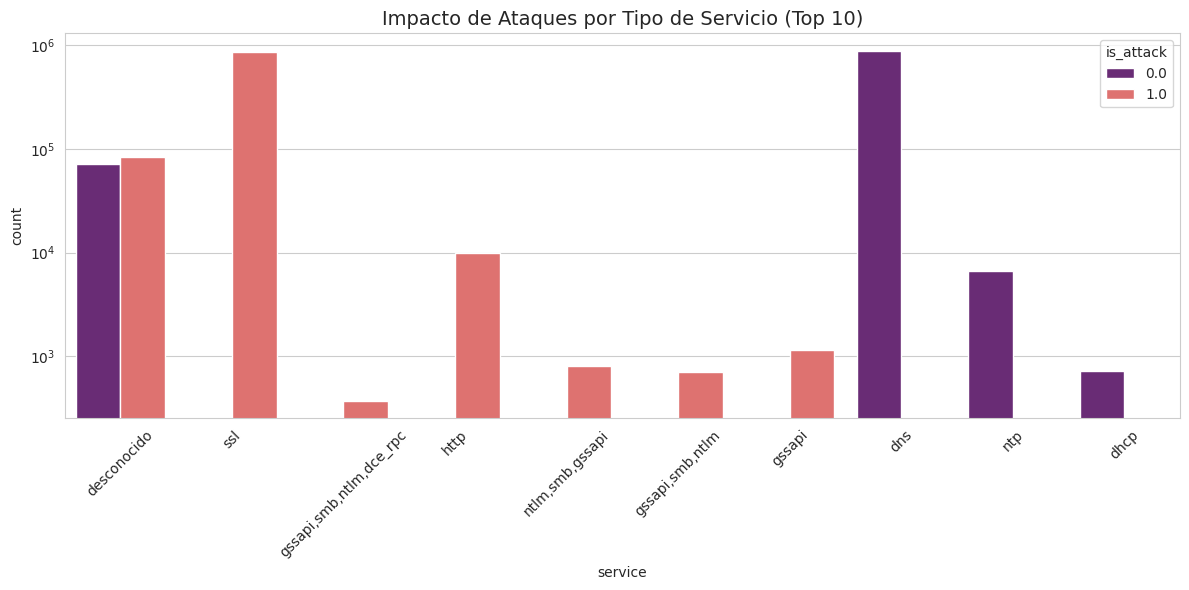

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# 1. LOCALIZACIÓN Y CARGA
archivos_parquet = glob.glob("*.parquet")
print(f"Se han encontrado {len(archivos_parquet)} archivos Parquet.")

lista_df = []
for f in archivos_parquet:
    # Añadimos las columnas numéricas que Zeek nos da para las Edge Features
    columnas_interes = ['service', 'label_tactic', 'src_ip_zeek', 'dest_ip_zeek', 
                        'duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts']
    temp_df = pd.read_parquet(f, columns=columnas_interes)
    lista_df.append(temp_df)

df = pd.concat(lista_df, ignore_index=True)
print(f"¡Hecho! Dataset total con {len(df):,} registros cargados.")

# 2. LIMPIEZA DE ETIQUETAS
df['service'] = df['service'].replace(['-', ''], 'desconocido').fillna('desconocido')
df['is_attack'] = (df['label_tactic'].fillna('none').str.lower() != 'none').astype(float)

# 3. DIAGNÓSTICO
resumen = pd.DataFrame({
    'Cantidad': df['service'].value_counts(),
    'Porcentaje (%)': (df['service'].value_counts(normalize=True) * 100).round(2)
})
print("\n--- DISTRIBUCIÓN GLOBAL ---")
print(resumen.head())

# 4. VISUALIZACIÓN
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
top_10 = df['service'].value_counts().head(10).index
df_plot = df[df['service'].isin(top_10)]

sns.countplot(data=df_plot, x='service', hue='is_attack', palette='magma')
plt.title('Impacto de Ataques por Tipo de Servicio (Top 10)', fontsize=14)
plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Engineering (Nodos Inductivos y Aristas)

Para que el modelo sea verdaderamente inductivo y agnóstico a la IP, las características iniciales de los nodos (X) deben ser estadísticas de comportamiento.

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("1. Procesando Características de las Aristas (Edge Features)...")
edge_cols = ['duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts']
df[edge_cols] = df[edge_cols].fillna(0)

scaler_edges = StandardScaler()
edge_features_np = scaler_edges.fit_transform(df[edge_cols])

print("2. Procesando Características de los Nodos (Node Features Inductivas)...")
ips_unicas = pd.unique(df[['src_ip_zeek', 'dest_ip_zeek']].values.ravel('K'))

# USO DE NAMED AGGREGATION (Soluciona el error de las columnas)
# Calculamos estadísticas cuando la IP actúa como ORIGEN (Out)
out_stats = df.groupby('src_ip_zeek').agg(
    out_bytes_mean=('orig_bytes', 'mean'),
    out_pkts_mean=('orig_pkts', 'mean'),
    out_degree=('orig_bytes', 'count') # El conteo de conexiones
)

# Calculamos estadísticas cuando la IP actúa como DESTINO (In)
in_stats = df.groupby('dest_ip_zeek').agg(
    in_bytes_mean=('resp_bytes', 'mean'),
    in_pkts_mean=('resp_pkts', 'mean'),
    in_degree=('resp_bytes', 'count')
)

node_df = pd.DataFrame(index=ips_unicas)
node_df = node_df.join(out_stats).join(in_stats).fillna(0)

scaler_nodes = StandardScaler()
node_features_np = scaler_nodes.fit_transform(node_df.values)

print(f"-> Nodos procesados con éxito: {len(ips_unicas):,}")

1. Procesando Características de las Aristas (Edge Features)...
2. Procesando Características de los Nodos (Node Features Inductivas)...
-> Nodos procesados con éxito: 357


### Construcción del Grafo en PyTorch

In [8]:
import torch

print("Construyendo matriz de adyacencia...")
# Codificamos las IPs a índices numéricos (0 a N)
encoder = LabelEncoder()
encoder.fit(ips_unicas)
df['src_id'] = encoder.transform(df['src_ip_zeek'])
df['dst_id'] = encoder.transform(df['dest_ip_zeek'])

# 1. Matriz de Adyacencia Global (edge_index) [2, num_aristas]
origen = torch.tensor(df['src_id'].values, dtype=torch.long)
destino = torch.tensor(df['dst_id'].values, dtype=torch.long)
edge_index_total = torch.stack([origen, destino], dim=0)

# 2. Tensores de Características (X) y Aristas (Edge_Attr)
x_nodos = torch.tensor(node_features_np, dtype=torch.float)
edge_attr_total = torch.tensor(edge_features_np, dtype=torch.float)

# 3. Etiquetas
y_total = torch.tensor(df['is_attack'].values, dtype=torch.float)
edge_services = df['service'].values

print(f"Tensor X (Nodos): {x_nodos.shape}")
print(f"Tensor edge_index (Topología): {edge_index_total.shape}")

Construyendo matriz de adyacencia...
Tensor X (Nodos): torch.Size([357, 6])
Tensor edge_index (Topología): torch.Size([2, 1916757])


### Enrutador y Partición Estratificada Train/Test

In [9]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Estratificación
df['stratify_key'] = df['service'] + '_' + df['is_attack'].astype(int).astype(str)
conteo_clases = df['stratify_key'].value_counts()
clases_validas = conteo_clases[conteo_clases > 1].index

indices_validos = df.index[df['stratify_key'].isin(clases_validas)].tolist()
idx_train, idx_test = train_test_split(
    indices_validos, 
    test_size=0.20, 
    random_state=42, 
    stratify=df.loc[indices_validos, 'stratify_key']
)

train_mask = torch.zeros(len(df), dtype=torch.bool)
test_mask = torch.zeros(len(df), dtype=torch.bool)
train_mask[idx_train] = True
test_mask[idx_test] = True

# 2. SEPARACIÓN DEL COMITÉ (Basado en el EDA)
servicios = df['service'].values
is_ataque = df['is_attack'].values

# Definimos los 3 grupos lógicos
mask_web = np.isin(servicios, ['ssl', 'http'])
mask_infra = np.isin(servicios, ['dns', 'ntp', 'dhcp'])
mask_gen = ~(mask_web | mask_infra) # El 8.06% "desconocido" y otros oscuros

# --- SOLUCIÓN A LA VARIANZA (El truco del Data Leakage) ---
# Como Web es 100% ataque, necesitamos inyectarle algunos benignos para entrenar.
# Como Infra es 100% benigno, necesitamos inyectarle ataques para entrenar.
# Tomaremos prestados ejemplos del grupo 'Generalista' que sí está balanceado.

benignos_disponibles = mask_gen & (is_ataque == 0)
ataques_disponibles = mask_gen & (is_ataque == 1)

# Máscaras de Entrenamiento para los Expertos (Inyección de varianza)
mask_train_web = (mask_web | benignos_disponibles)
mask_train_infra = (mask_infra | ataques_disponibles)

# Convertimos a tensores para PyTorch (Y aplicamos el split de train/test)
train_mask_web = torch.tensor(mask_train_web, dtype=torch.bool) & train_mask
test_mask_web = torch.tensor(mask_web, dtype=torch.bool) & test_mask # En Test/Producción es estricto

train_mask_infra = torch.tensor(mask_train_infra, dtype=torch.bool) & train_mask
test_mask_infra = torch.tensor(mask_infra, dtype=torch.bool) & test_mask # En Test/Producción es estricto

train_mask_gen = torch.tensor(mask_gen, dtype=torch.bool) & train_mask
test_mask_gen = torch.tensor(mask_gen, dtype=torch.bool) & test_mask

print("\n--- DISTRIBUCIÓN DEL COMITÉ PARA ENTRENAMIENTO ---")
print(f"Experto Web (con varianza inyectada): {train_mask_web.sum().item():,} aristas")
print(f"Experto Infra (con varianza inyectada): {train_mask_infra.sum().item():,} aristas")
print(f"Experto Generalista: {train_mask_gen.sum().item():,} aristas")


--- DISTRIBUCIÓN DEL COMITÉ PARA ENTRENAMIENTO ---
Experto Web (con varianza inyectada): 753,378 aristas
Experto Infra (con varianza inyectada): 780,027 aristas
Experto Generalista: 127,574 aristas


### Arquitectura GraphSAGE (El Modelo)

In [10]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class EdgeExpertSAGE(torch.nn.Module):
    def __init__(self, node_in_channels, edge_in_channels, hidden_channels):
        super(EdgeExpertSAGE, self).__init__()
        
        # 1. Capas GraphSAGE (Paso de mensajes)
        self.conv1 = SAGEConv(node_in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        
        # 2. Clasificador Perceptrón (Evalúa la conexión)
        # Input: IP_Src(emb) + IP_Dst(emb) + Zeek_Features
        clf_input_dim = (hidden_channels * 2) + edge_in_channels
        self.edge_classifier = nn.Sequential(
            nn.Linear(clf_input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid() 
        )

    def forward(self, x, edge_index_msg, edge_index_pred, edge_attr_pred):
        # Fase 1: Entender el contexto usando TODA la red (Message Passing)
        x = self.conv1(x, edge_index_msg)
        x = F.relu(x)
        x = self.conv2(x, edge_index_msg)
        
        # Fase 2: Predecir SOLO para las aristas que nos piden
        src = edge_index_pred[0]
        dst = edge_index_pred[1]
        
        edge_features = torch.cat([x[src], x[dst], edge_attr_pred], dim=-1)
        
        return self.edge_classifier(edge_features)

### Bucle de Entrenamiento (Experto Generalista)

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Entrenando en: {device}")

# Instanciamos el modelo
model_gen = EdgeExpertSAGE(
    node_in_channels=x_nodos.shape[1], 
    edge_in_channels=edge_attr_total.shape[1], 
    hidden_channels=32
).to(device)

optimizer = torch.optim.Adam(model_gen.parameters(), lr=0.005)
criterion = nn.BCELoss()

# Movemos los datos globales a la memoria
x_nodos = x_nodos.to(device)
edge_index_total = edge_index_total.to(device)

# Preparamos los datos específicos del Generalista para TRAIN
edge_index_train_gen = edge_index_total[:, train_mask_gen]
edge_attr_train_gen = edge_attr_total[train_mask_gen].to(device)
y_train_gen = y_total[train_mask_gen].to(device)

# Bucle de Entrenamiento
epochs = 50
model_gen.train()

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Pasamos: Nodos globales, Topología global, Aristas objetivo, Atributos objetivo
    out = model_gen(x_nodos, edge_index_total, edge_index_train_gen, edge_attr_train_gen)
    
    loss = criterion(out.squeeze(), y_train_gen)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        # Calcular Accuracy básico en Train
        preds = (out.squeeze() > 0.5).float()
        acc = (preds == y_train_gen).sum().item() / len(y_train_gen)
        print(f'Epoch: {epoch+1:03d}, Loss: {loss.item():.4f}, Train Acc: {acc:.4f}')

Entrenando en: cuda
Epoch: 010, Loss: 0.4128, Train Acc: 0.9219
Epoch: 020, Loss: 0.1787, Train Acc: 0.9589
Epoch: 030, Loss: 0.1448, Train Acc: 0.9660
Epoch: 040, Loss: 0.1292, Train Acc: 0.9699
Epoch: 050, Loss: 0.1204, Train Acc: 0.9716


### Evaluación en el Conjunto de Test


--- REPORTE DE EVALUACIÓN (EXPERTO GENERALISTA) ---
              precision    recall  f1-score   support

 Benigno (0)       1.00      0.94      0.97     14254
  Ataque (1)       0.95      1.00      0.98     17638

    accuracy                           0.97     31892
   macro avg       0.98      0.97      0.97     31892
weighted avg       0.97      0.97      0.97     31892



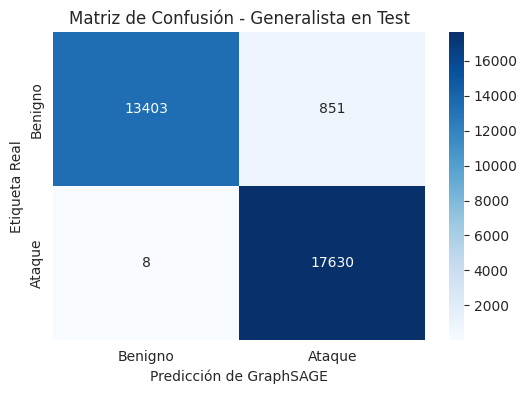

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

model_gen.eval()

# Preparamos los datos específicos del Generalista para TEST
edge_index_test_gen = edge_index_total[:, test_mask_gen]
edge_attr_test_gen = edge_attr_total[test_mask_gen].to(device)
y_test_gen = y_total[test_mask_gen].to(device)

with torch.no_grad():
    out_test = model_gen(x_nodos, edge_index_total, edge_index_test_gen, edge_attr_test_gen)
    preds_test = (out_test.squeeze() > 0.5).float().cpu().numpy()

y_true = y_test_gen.cpu().numpy()

print("\n--- REPORTE DE EVALUACIÓN (EXPERTO GENERALISTA) ---")
print(classification_report(y_true, preds_test, target_names=['Benigno (0)', 'Ataque (1)']))

# Matriz de confusión
cm = confusion_matrix(y_true, preds_test)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benigno', 'Ataque'], yticklabels=['Benigno', 'Ataque'])
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción de GraphSAGE')
plt.title('Matriz de Confusión - Generalista en Test')
plt.show()